In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from tqdm import tqdm
import pickle
from pathlib import Path
import importlib
from glob import glob
import re

import Particles_2D
importlib.reload(Particles_2D)
from Particles_2D import Particles_2D
from Particles_2D import coldstart_finder

In [47]:
with open(r"coldstart_pickles\d_0.291_N_1000.pkl","rb") as f:
    coldstart = pickle.load(f)
    R = coldstart.R
    

In [109]:
with open(r"runs\equilibrium\equ_0.291_0.3_100.pkl","rb") as f:
    coldstart = pickle.load(f)
    R = coldstart.R

In [131]:
coldstart.print_status()

Overlaps: 0
Energy: inf
Accepted movements: 331
Completed iterations: 1869
Acceptance ratio:0.18


System Parameters
Number of particles:100
Density*:0.291
Temperature*:10
Delta Step:2.2


In [132]:
coldstart= Particles_2D(N=100,density=0.291,temperature=0.1,R=R,delta_step=0.4)

In [133]:
coldstart.run_mc(max_iter=2*(10**6),equilibrium=True,delta_optim=False)

100%|██████████| 2000000/2000000 [00:32<00:00, 62081.76it/s]


In [ ]:
len(coldstart.equilibrium_array)

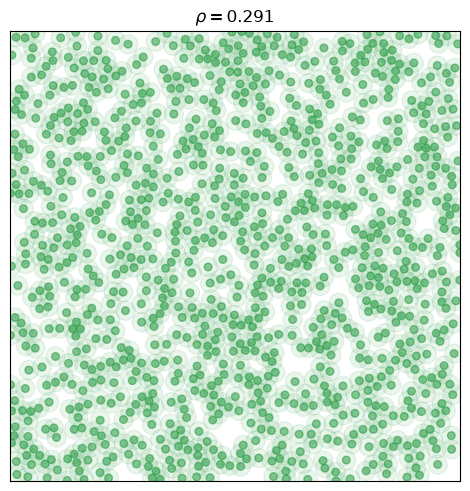

In [36]:
coldstart.scatter()

In [17]:
coldstart.print_status()

Overlaps: 0
Energy: inf
Accepted movements: 23320
Completed iterations: 47003
Acceptance ratio:0.5


System Parameters
Number of particles:1000
Density*:0.291
Temperature*:0.2
Delta Step:2


In [48]:
temp_drop_starter = Particles_2D(N=1000,temperature=0.25,density=0.291,R=R)

In [ ]:
temp_drop_starter.run_mc(max_iter=2*(10**8),equilibrium=False,production=True)

  0%|          | 0/200000000 [00:00<?, ?it/s]

 18%|█▊        | 36729620/200000000 [19:54<1:17:34, 35076.38it/s]

In [49]:
temp_drop_starter.print_status()

Overlaps: 0
Energy: 1407
Accepted movements: 854053
Completed iterations: 2000000
Acceptance ratio:0.43


System Parameters
Number of particles:1000
Density*:0.291
Temperature*:0.25
Delta Step:0.4


In [49]:
temp_drop_starter.print_status()

Overlaps: 0
Energy: 2537
Accepted movements: 0
Completed iterations: 0
Acceptance ratio:0.0


System Parameters
Number of particles:1000
Density*:0.291
Temperature*:0.25
Delta Step:0.4


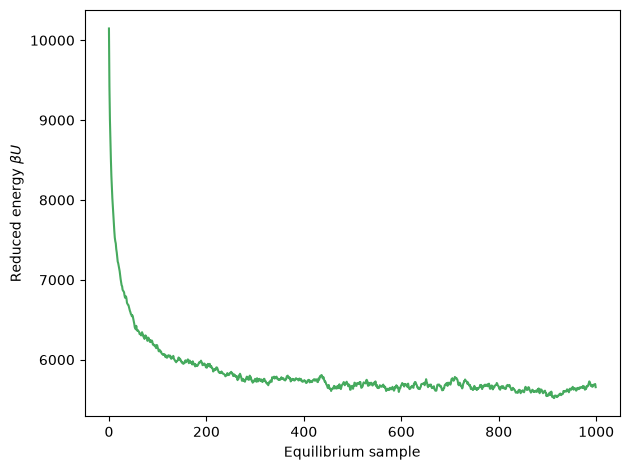

In [51]:

energy_equilibrium = -np.array(temp_drop_starter.equilibrium_array)

fig, ax = plt.subplots()
ax.plot(energy_equilibrium, color="#189536cc", linewidth=1.5)

ax.set_xlabel("Equilibrium sample")
ax.set_ylabel(r"Reduced energy $\beta U$")
plt.tight_layout()
plt.show()

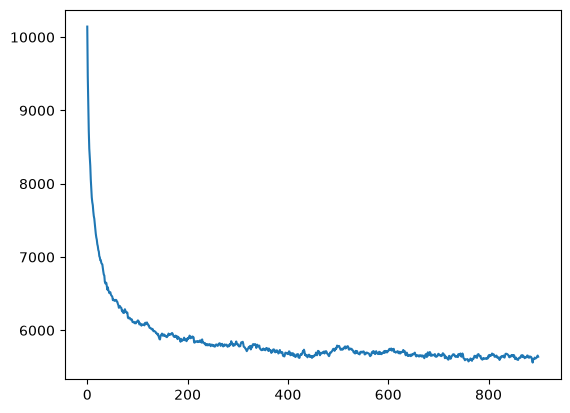

In [19]:
plt.plot(-np.array(temp_drop_starter.equilibrium_array)[:-100])

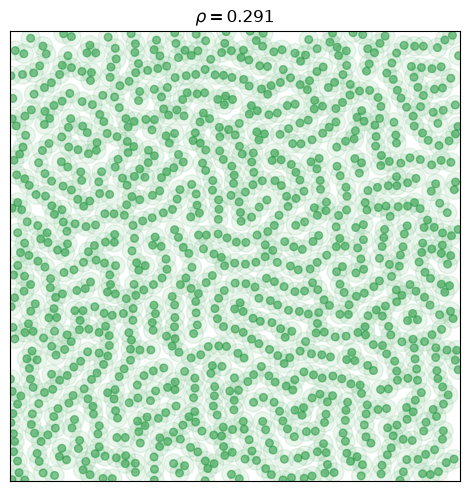

In [18]:
temp_drop_starter.scatter()

In [52]:
temp_drop_starter.state_snapshot()

In [53]:
temp_drop_starter.run_mc(production=True)

100%|██████████| 20000000/20000000 [44:20<00:00, 7516.41it/s] 


In [ ]:
(temp_drop_starter.energy_M2/(2*(10**7)-1))

np.float64(180572.15613776885)